# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df_awal = pd.read_csv('Food_Delivery_Times.csv')
df_awal

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
5,679,19.40,Clear,Low,Evening,Scooter,8,9.0,57
6,627,9.52,Clear,Low,NaN,Bike,12,1.0,49
7,514,17.39,Clear,Medium,Evening,Scooter,5,6.0,46
8,860,1.78,Snowy,Low,Evening,Car,20,6.0,35
9,137,10.62,Foggy,Low,Evening,Scooter,29,1.0,73


# Variable Description

| No | Variable Name            | Data Type        | Description                                                                 |
|----|--------------------------|------------------|-----------------------------------------------------------------------------|
| 1  | Order_ID                 | Integer / String | Unique identifier untuk setiap pesanan                                      |
| 2  | Distance_km              | Float            | Jarak pengiriman dari lokasi asal ke tujuan (dalam kilometer)              |
| 3  | Weather                  | Categorical      | Kondisi cuaca saat pengiriman (misalnya: Sunny, Rainy, Stormy, dll.)       |
| 4  | Traffic_Level            | Categorical      | Tingkat kepadatan lalu lintas (Low, Medium, High)                          |
| 5  | Time_of_Day              | Categorical      | Waktu pengiriman (Morning, Afternoon, Evening, Night)                      |
| 6  | Vehicle_Type             | Categorical      | Jenis kendaraan yang digunakan kurir (Bike, Car, dll.)                     |
| 7  | Preparation_Time_min     | Integer          | Waktu persiapan sebelum pengiriman dimulai (dalam menit)                   |
| 8  | Courier_Experience_yrs   | Integer / Float  | Lama pengalaman kurir dalam tahun                                          |
| 9  | Delivery_Time_min        | Integer / Float  | Total waktu yang dibutuhkan untuk pengiriman (dalam menit)                 |

# Data Understanding

In [3]:
# ringkasan dataset
df_awal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [4]:
df_awal.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


1. Rata-rata jarak pengiriman sekitar 10 km dengan variasi yang cukup lebar (0.59 km hingga 19.99 km), menunjukkan adanya kombinasi pengiriman jarak dekat hingga jauh.

2. Waktu persiapan memiliki rata-rata sekitar 17 menit, dengan rentang 5 hingga 29 menit, yang menunjukkan variasi operasional dalam proses persiapan pesanan.

3. Pengalaman kurir rata-rata berada di sekitar 4–5 tahun, namun terdapat beberapa kurir dengan pengalaman 0 tahun serta adanya data yang tidak lengkap (missing).

4. Sementara itu, waktu pengiriman memiliki rata-rata sekitar 56.7 menit, dengan rentang yang cukup luas dari 8 menit hingga 153 menit, yang mengindikasikan adanya variasi signifikan dalam durasi pengiriman.

In [5]:
# Memeriksa Duplicate Value
duplicate_count = df_awal.duplicated().sum()
print("Total duplicate rows:", duplicate_count)

Total duplicate rows: 0


In [6]:
df_awal[df_awal.isnull().any(axis=1)][['Weather', 'Traffic_Level', 'Time_of_Day', 'Courier_Experience_yrs']]

,Weather,Traffic_Level,Time_of_Day,Courier_Experience_yrs
6,Clear,Low,NaN,1.0
14,Clear,High,Morning,NaN
24,Clear,Medium,Morning,NaN
42,NaN,Medium,Evening,NaN
71,NaN,Low,Evening,1.0
85,Clear,NaN,Afternoon,8.0
90,Windy,High,Morning,NaN
95,Clear,Low,NaN,7.0
110,Foggy,Low,Night,NaN
113,Clear,Medium,NaN,5.0


In [7]:
missing_data = df_awal.isnull().sum()

missing_summary = pd.DataFrame({
    'Jumlah Data Kosong': missing_data,
    'Persentase (%)': (missing_data / len(df_awal) * 100).round(2)
})

missing_summary

,Jumlah Data Kosong,Persentase (%)
Order_ID,0,0.0
Distance_km,0,0.0
Weather,30,3.0
Traffic_Level,30,3.0
Time_of_Day,30,3.0
Vehicle_Type,0,0.0
Preparation_Time_min,0,0.0
Courier_Experience_yrs,30,3.0
Delivery_Time_min,0,0.0


1. Beberapa kolom seperti Weather, Traffic_Level, Time_of_Day, dan Courier_Experience_yrs memiliki missing value sebesar 3%. 

2. Persentase ini relatif kecil sehingga masih dapat ditoleransi dan tidak memberikan dampak signifikan terhadap hasil analisis.

In [8]:
# Memeriksa Unique Value
pd.set_option('display.max_colwidth', None)
unique_summary = pd.DataFrame({
    'n_unique': df_awal.nunique(),
    'unique_values': df_awal.apply(lambda x: x.unique())
})

unique_summary

,n_unique,unique_values
Order_ID,1000,"[522, 738, 741, 661, 412, 679, 627, 514, 860, 137, 812, 77, 637, 974, 939, 900, 281, 884, 762, 320, 550, 175, 372, 528, 211, 236, 102, 987, 903, 948, 347, 140, 622, 500, 371, 199, 688, 585, 902, 60, 329, 97, 313, 975, 300, 278, 925, 602, 440, 838, 571, 880, 262, 579, 24, 31, 618, 11, 222, 821, 297, 55, 543, 210, 605, 693, 663, 867, 71, 544, 108, 494, 591, 742, 293, 290, 653, 40, 590, 308, 680, 67, 276, 68, 319, 549, 999, 715, 754, 328, 383, 452, 523, 219, 788, 437, 765, 89, 64, 827, ...]"
Distance_km,785,"[7.93, 16.42, 9.52, 7.44, 19.03, 19.4, 17.39, 1.78, 10.62, 16.86, 15.54, 10.89, 4.69, 2.8, 2.17, 17.86, 2.53, 6.58, 5.38, 15.56, 13.08, 0.86, 5.83, 11.2, 14.59, 12.91, 13.92, 4.04, 18.05, 12.88, 19.45, 4.58, 19.73, 2.47, 17.8, 5.96, 12.85, 1.02, 6.84, 8.68, 10.69, 0.99, 1.11, 2.16, 13.17, 8.79, 5.93, 2.09, 7.57, 10.52, 4.83, 19.81, 10.1, 7.64, 12.35, 5.9, 0.9, 11.58, 16.16, 15.51, 12.16, 4.96, 3.64, 2.85, 10.4, 12.31, 3.53, 13.6, 15.23, 4.17, 3.21, 6.38, 16.54, 12.02, 11.94, 9.08, 3.46, 6.8, 17.38, 3.25, 10.28, 16.14, 3.55, 10.65, 7.3, 7.03, 12.43, 12.76, 11.39, 19.41, 8.32, 1.92, 1.15, 7.46, 7.25, 16.7, 17.2, 18.76, 9.22, 2.84, ...]"
Weather,5,"[Windy, Clear, Foggy, Rainy, Snowy, nan]"
Traffic_Level,3,"[Low, Medium, High, nan]"
Time_of_Day,4,"[Afternoon, Evening, Night, Morning, nan]"
Vehicle_Type,3,"[Scooter, Bike, Car]"
Preparation_Time_min,25,"[12, 20, 28, 5, 16, 8, 29, 13, 10, 15, 6, 26, 27, 23, 11, 18, 22, 25, 14, 19, 21, 17, 9, 7, 24]"
Courier_Experience_yrs,10,"[1.0, 2.0, 5.0, 9.0, 6.0, 4.0, 7.0, nan, 3.0, 8.0, 0.0]"
Delivery_Time_min,108,"[43, 84, 59, 37, 68, 57, 49, 46, 35, 73, 88, 76, 53, 36, 33, 50, 24, 27, 47, 72, 58, 56, 64, 70, 123, 52, 108, 45, 111, 44, 61, 34, 67, 32, 8, 104, 31, 23, 82, 69, 60, 40, 38, 54, 87, 62, 22, 42, 51, 41, 48, 92, 71, 65, 28, 74, 14, 30, 94, 80, 91, 79, 77, 26, 141, 78, 29, 105, 16, 116, 75, 25, 113, 17, 66, 85, 100, 21, 89, 55, 96, 13, 90, 112, 63, 39, 101, 93, 83, 109, 20, 19, 153, 102, 103, 86, 115, 15, 98, 106, ...]"


In [9]:
# Memeriksa Outlier
num_cols = df_awal.select_dtypes(include="number").columns

Q1 = df_awal[num_cols].quantile(0.25)
Q3 = df_awal[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_summary = pd.DataFrame({
    "Jumlah Outlier": ((df_awal[num_cols] < lower) | (df_awal[num_cols] > upper)).sum(),
    "Persentase Outlier (%)": (
        ((df_awal[num_cols] < lower) | (df_awal[num_cols] > upper)).sum() / len(df_awal) * 100
    ).round(2),
    "Nilai Skewness": df_awal[num_cols].skew()
})

outlier_summary

,Jumlah Outlier,Persentase Outlier (%),Nilai Skewness
Order_ID,0,0.0,0.000000
Distance_km,0,0.0,0.038840
Preparation_Time_min,0,0.0,0.030008
Courier_Experience_yrs,0,0.0,-0.029087
Delivery_Time_min,6,0.6,0.507251


1. Sebagian besar variabel tidak menunjukkan adanya outlier, yang mengindikasikan bahwa data relatif bersih dan stabil untuk dianalisis.

2. Namun, pada variabel Delivery Time terdapat sedikit outlier (0.6%), yang menunjukkan adanya beberapa kasus pengiriman dengan durasi yang jauh lebih lama dari kondisi normal.

3. Dari sisi distribusi, nilai skewness pada hampir semua variabel mendekati nol, sehingga distribusinya cenderung simetris. 

4. Sementara itu, Delivery Time memiliki skewness positif (~0.51), yang menunjukkan adanya kecenderungan nilai yang lebih tinggi (pengiriman yang lebih lama) meskipun tidak terlalu ekstrem.

=== HASIL UJI NORMALITAS (ANDERSON-DARLING) ===

Variable: Order_ID
Statistic: 11.0850
Critical Value (5%): 0.7840
Conclusion: Not Normally Distributed ❌
Skewness: 0.0000
Skewness Info: Symmetric

Variable: Distance_km
Statistic: 12.5195
Critical Value (5%): 0.7840
Conclusion: Not Normally Distributed ❌
Skewness: 0.0388
Skewness Info: Right Skew

Variable: Preparation_Time_min
Statistic: 13.6007
Critical Value (5%): 0.7840
Conclusion: Not Normally Distributed ❌
Skewness: 0.0300
Skewness Info: Right Skew

Variable: Delivery_Time_min
Statistic: 2.9761
Critical Value (5%): 0.7840
Conclusion: Not Normally Distributed ❌
Skewness: 0.5073
Skewness Info: Right Skew

=== RINGKASAN (TABLE) ===


,Variable,Statistic,Critical Value (5%),Conclusion,Skewness,Skewness Info
0,Order_ID,11.0850,0.784,Not Normal,0.0000,Symmetric
1,Distance_km,12.5195,0.784,Not Normal,0.0388,Right Skew
2,Preparation_Time_min,13.6007,0.784,Not Normal,0.0300,Right Skew
3,Delivery_Time_min,2.9761,0.784,Not Normal,0.5073,Right Skew


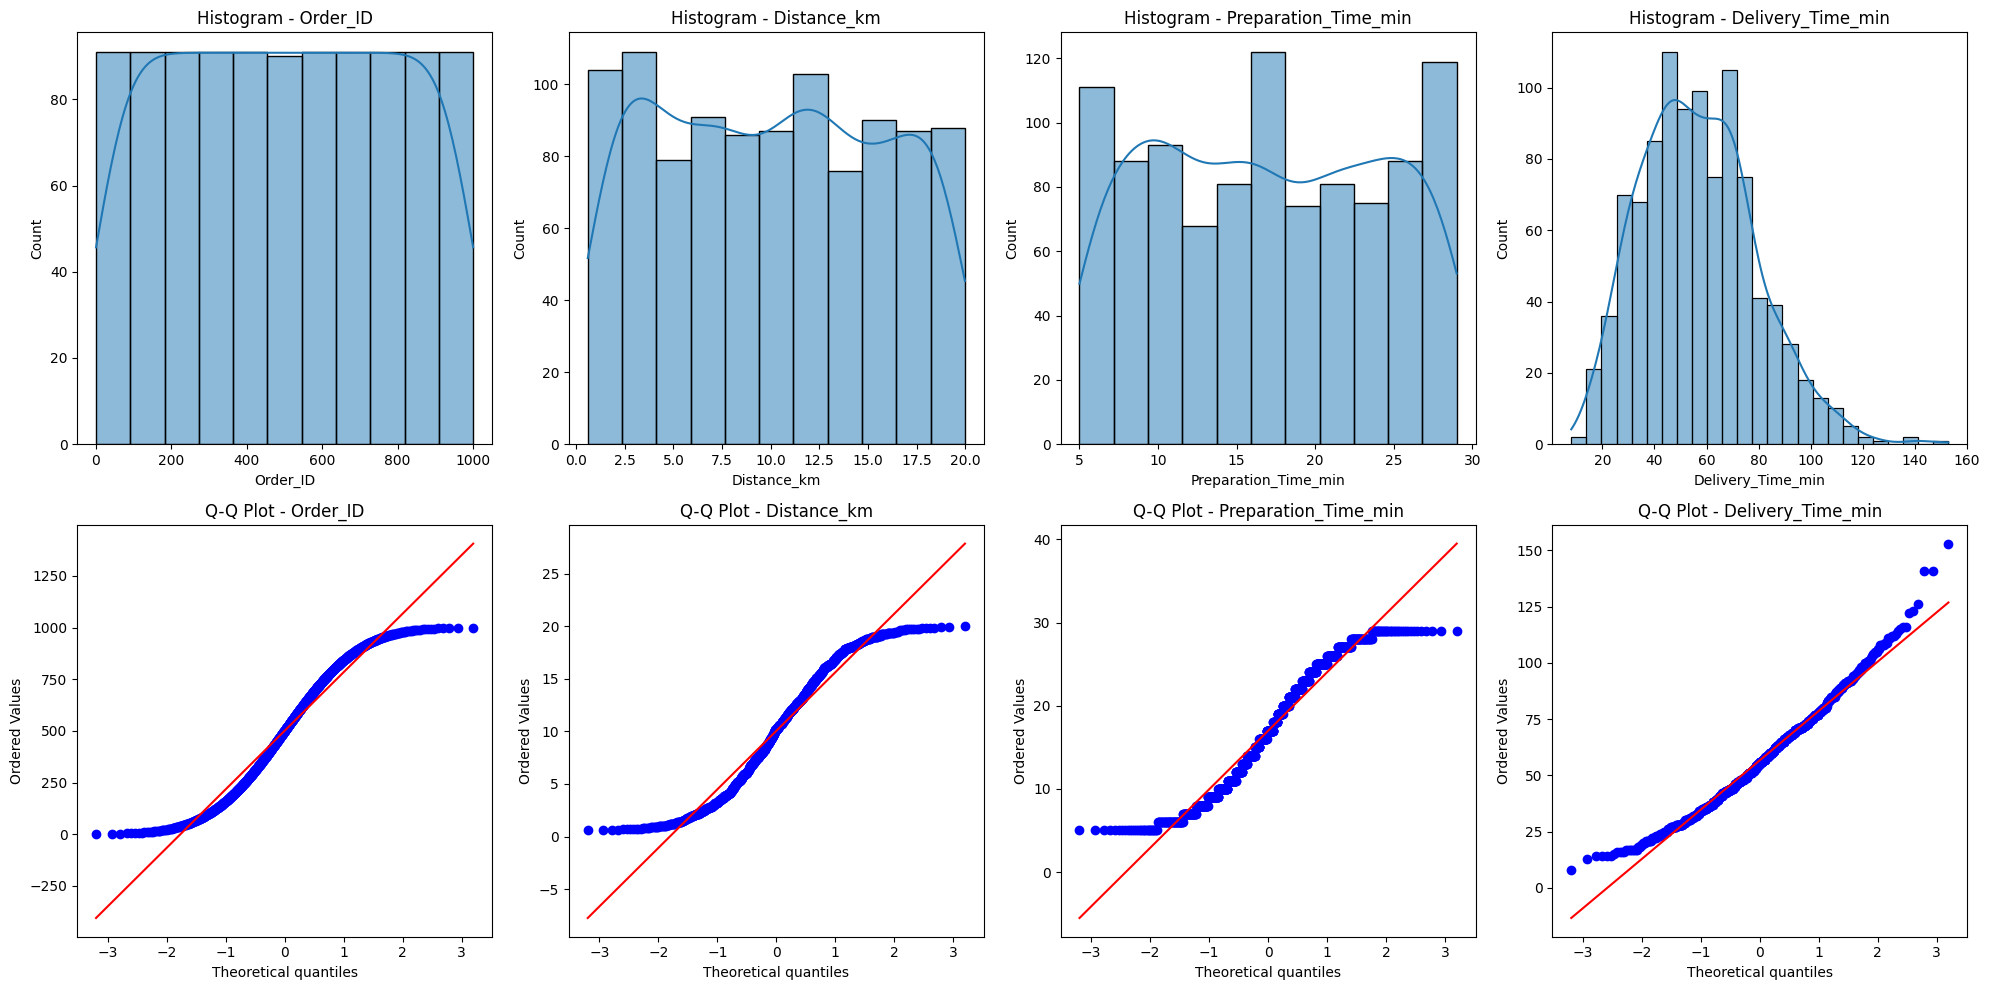

In [10]:
from scipy import stats

# Ambil kolom numerik (exclude binary)
cols = [
    col for col in df_awal.select_dtypes(include=['number']).columns
    if df_awal[col].nunique() > 10
]

results = []

print("=== HASIL UJI NORMALITAS (ANDERSON-DARLING) ===")

# =======================
# LOOP ANALISIS + PRINT
# =======================
for col in cols:
    data = df_awal[col].dropna()
    result = stats.anderson(data, dist='norm')
    stat = result.statistic
    crit_val = result.critical_values[2]
    if stat > crit_val:
        conclusion = "Not Normally Distributed ❌"
        short_conclusion = "Not Normal"
    else:
        conclusion = "Normally Distributed ✅"
        short_conclusion = "Normal"
    
    skewness = data.skew()
    
    if skewness > 0:
        skew_info = "Right Skew"
    elif skewness < 0:
        skew_info = "Left Skew"
    else:
        skew_info = "Symmetric"
    
    # PRINT DETAIL
    print(f"\n{'='*50}")
    print(f"Variable: {col}")
    print(f"{'='*50}")
    print(f"Statistic: {stat:.4f}")
    print(f"Critical Value (5%): {crit_val:.4f}")
    print(f"Conclusion: {conclusion}")
    print(f"Skewness: {skewness:.4f}")
    print(f"Skewness Info: {skew_info}")
    
    # SIMPAN KE TABLE
    results.append({
        'Variable': col,
        'Statistic': round(stat, 4),
        'Critical Value (5%)': round(crit_val, 4),
        'Conclusion': short_conclusion,
        'Skewness': round(skewness, 4),
        'Skewness Info': skew_info
    })

# TABEL RINGKASAN
df_normality = pd.DataFrame(results)

print("\n=== RINGKASAN (TABLE) ===")
display(df_normality)

# VISUALISASI GRID (JEJER KE SAMPING)
n = len(cols)

fig, axes = plt.subplots(2, n, figsize=(5*n, 10))

for i, col in enumerate(cols):
    data = df_awal[col].dropna()
    # Histogram
    sns.histplot(data, kde=True, ax=axes[0, i])
    axes[0, i].set_title(f'Histogram - {col}')
    # QQ Plot
    stats.probplot(data, dist="norm", plot=axes[1, i])
    axes[1, i].set_title(f'Q-Q Plot - {col}')

plt.tight_layout()
plt.show()

1. Hasil analisis menunjukkan bahwa seluruh variabel numerik tidak sepenuhnya mengikuti distribusi normal, yang terlihat dari hasil uji normalitas serta pola pada Q-Q plot yang menyimpang dari garis diagonal.

2. Variabel Distance dan Preparation Time menunjukkan sedikit kecenderungan ke arah kanan (right skew), namun tidak terlalu ekstrem, sehingga distribusinya masih relatif stabil.

3. Sementara itu, Delivery Time memiliki kecenderungan right skew yang lebih jelas, yang menunjukkan adanya beberapa nilai yang lebih tinggi (durasi pengiriman yang lebih lama) dibandingkan mayoritas data.

4. Secara keseluruhan, meskipun data tidak sepenuhnya berdistribusi normal, pola distribusinya masih cukup wajar dan tidak menunjukkan penyimpangan ekstrem yang dapat mengganggu analisis.

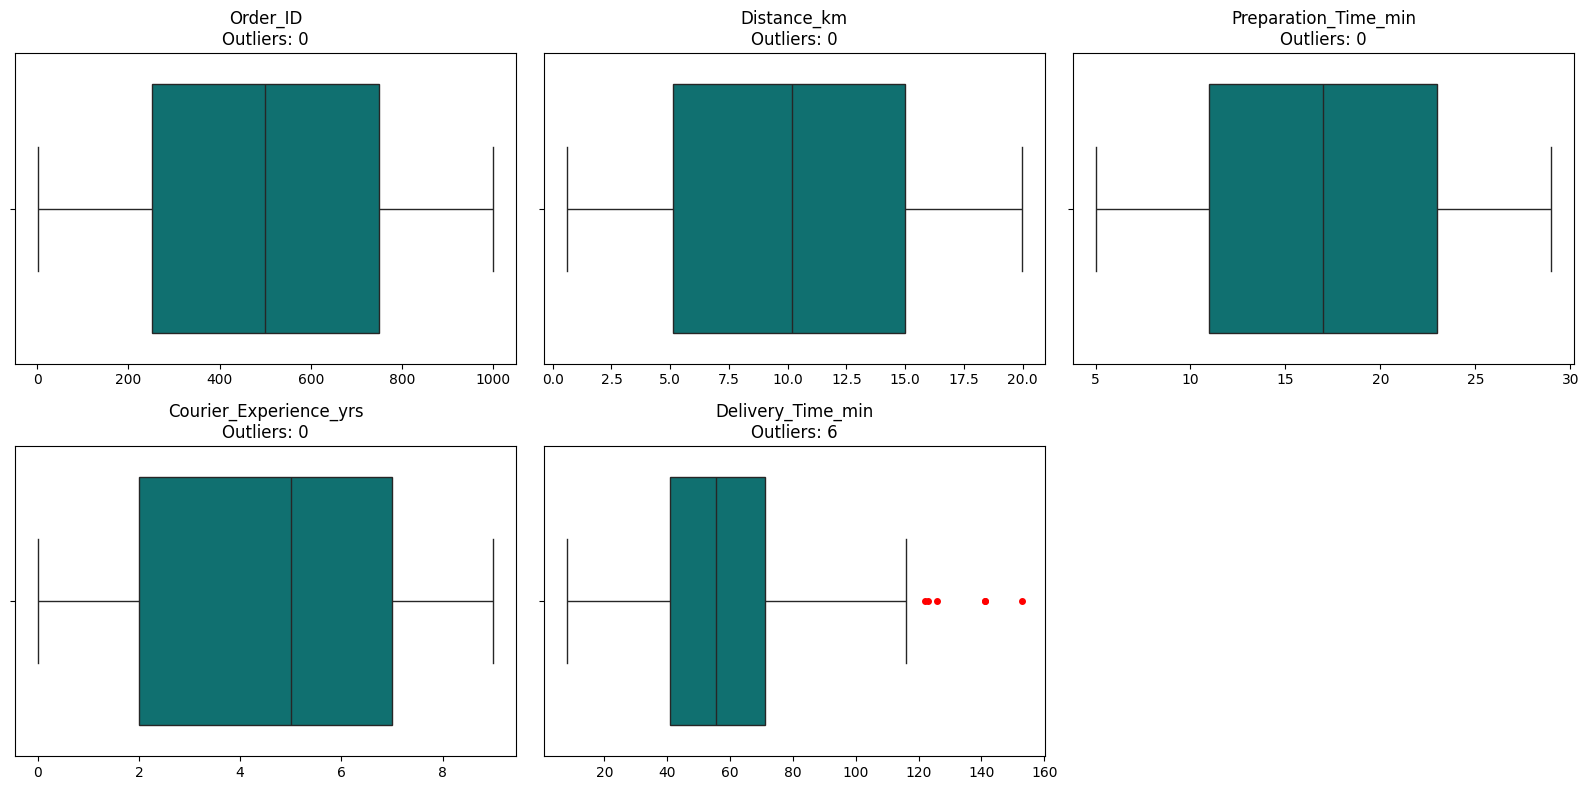

In [11]:
# boxplot visualisasi untuk melihat outlier value

# Ambil semua kolom numerik
num_cols = df_awal.select_dtypes(include='number').columns

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16,8))
axes = axes.flatten()

for i, col in enumerate(num_cols):

    # hitung outlier (IQR)
    Q1 = df_awal[col].quantile(0.25)
    Q3 = df_awal[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_awal[(df_awal[col] < lower) | (df_awal[col] > upper)]
    n_outliers = len(outliers)

    sns.boxplot(
        x=df_awal[col],
        ax=axes[i],
        color='teal',
        flierprops=dict(
            marker='o',
            markerfacecolor='red',
            markeredgecolor='red',
            markersize=4
        )
    )

    axes[i].set_title(f"{col}\nOutliers: {n_outliers:,}")
    axes[i].set_xlabel("")

# hapus subplot kosong
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

1. Sebagian besar variabel seperti Distance, Preparation Time, dan Courier Experience tidak menunjukkan adanya outlier, yang menandakan data relatif bersih dan stabil.

2. Outlier hanya ditemukan pada Delivery Time dan tidak dihapus karena mencerminkan kondisi operasional nyata. Jumlahnya yang sangat kecil (0.6%) juga tidak berdampak signifikan terhadap analisis, sehingga tetap dipertahankan.

# Data Preprocessing

In [12]:
# inisialisasi dataframe untuk proses cleaning
df_cleaning = df_awal.copy()

## Handling Missing Value

### Categorical Variable

In [13]:
df_cleaning[df_cleaning.select_dtypes(include='object').columns] = df_cleaning.select_dtypes(include='object').fillna('Unknown')

### Numerical Variable

In [14]:
# Flag missing
df_cleaning['experience_missing_flag'] = df_cleaning['Courier_Experience_yrs'].isna().astype(int)

# Imputasi median (tanpa warning)
df_cleaning['Courier_Experience_yrs'] = df_cleaning['Courier_Experience_yrs'].fillna(
    df_cleaning['Courier_Experience_yrs'].median()
)

In [15]:
df_cleaning['Courier_Experience_yrs'].median()

5.0

Median digunakan karena lebih mewakili pengalaman kurir pada umumnya, sehingga hasil imputasi tetap mencerminkan kondisi nyata di lapangan tanpa bias dari nilai yang terlalu tinggi atau rendah.

## Standardization Data Types

In [16]:
# Convert object columns to category
cat_cols = df_cleaning.select_dtypes(include='object').columns

for col in cat_cols:
    df_cleaning[col] = df_cleaning[col].astype('category')

# Validation
df_cleaning.dtypes

Order_ID                      int64
Distance_km                 float64
Weather                    category
Traffic_Level              category
Time_of_Day                category
Vehicle_Type               category
Preparation_Time_min          int64
Courier_Experience_yrs      float64
Delivery_Time_min             int64
experience_missing_flag       int64
dtype: object

# Cleaned Dataset Overview

In [17]:
df_finals = df_cleaning.copy()

In [49]:
df_finals.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,experience_missing_flag,experience_level,distance_group,prep_time_group
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,0,Low (0-2),Medium (5-10),Normal Prep (10-20)
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84,0,Low (0-2),Far (10+),Normal Prep (10-20)
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59,0,Low (0-2),Medium (5-10),Slow Prep (20+)
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,0,Low (0-2),Medium (5-10),Fast Prep (0-10)
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68,0,Medium (3-5),Far (10+),Normal Prep (10-20)


# Exploratory Data Analysis (EDA)

In [19]:
# inisalisasi df untuk process EDA
df_EDA = df_finals.copy()

In [20]:
# One Hot Encoding
df_EDA = pd.get_dummies(
    df_EDA,
    columns=['Weather','Traffic_Level','Time_of_Day','Vehicle_Type'],
    drop_first=False
)

# ubah boolean dummy menjadi 1 dan 0
bool_cols = df_EDA.select_dtypes(include='bool').columns
df_EDA[bool_cols] = df_EDA[bool_cols].astype(int)

# Mengatur tampilan kolom agar tidak terpotong
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

# Menampilkan hasil dataset setelah encoding
df_EDA

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,experience_missing_flag,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Unknown,Weather_Windy,Traffic_Level_High,Traffic_Level_Low,Traffic_Level_Medium,Traffic_Level_Unknown,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Time_of_Day_Unknown,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,12,1.0,43,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,1
1,738,16.42,20,2.0,84,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0
2,741,9.52,28,1.0,59,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1
3,661,7.44,5,1.0,37,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1
4,412,19.03,16,5.0,68,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0
5,679,19.40,8,9.0,57,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1
6,627,9.52,12,1.0,49,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0
7,514,17.39,5,6.0,46,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1
8,860,1.78,20,6.0,35,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0
9,137,10.62,29,1.0,73,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1


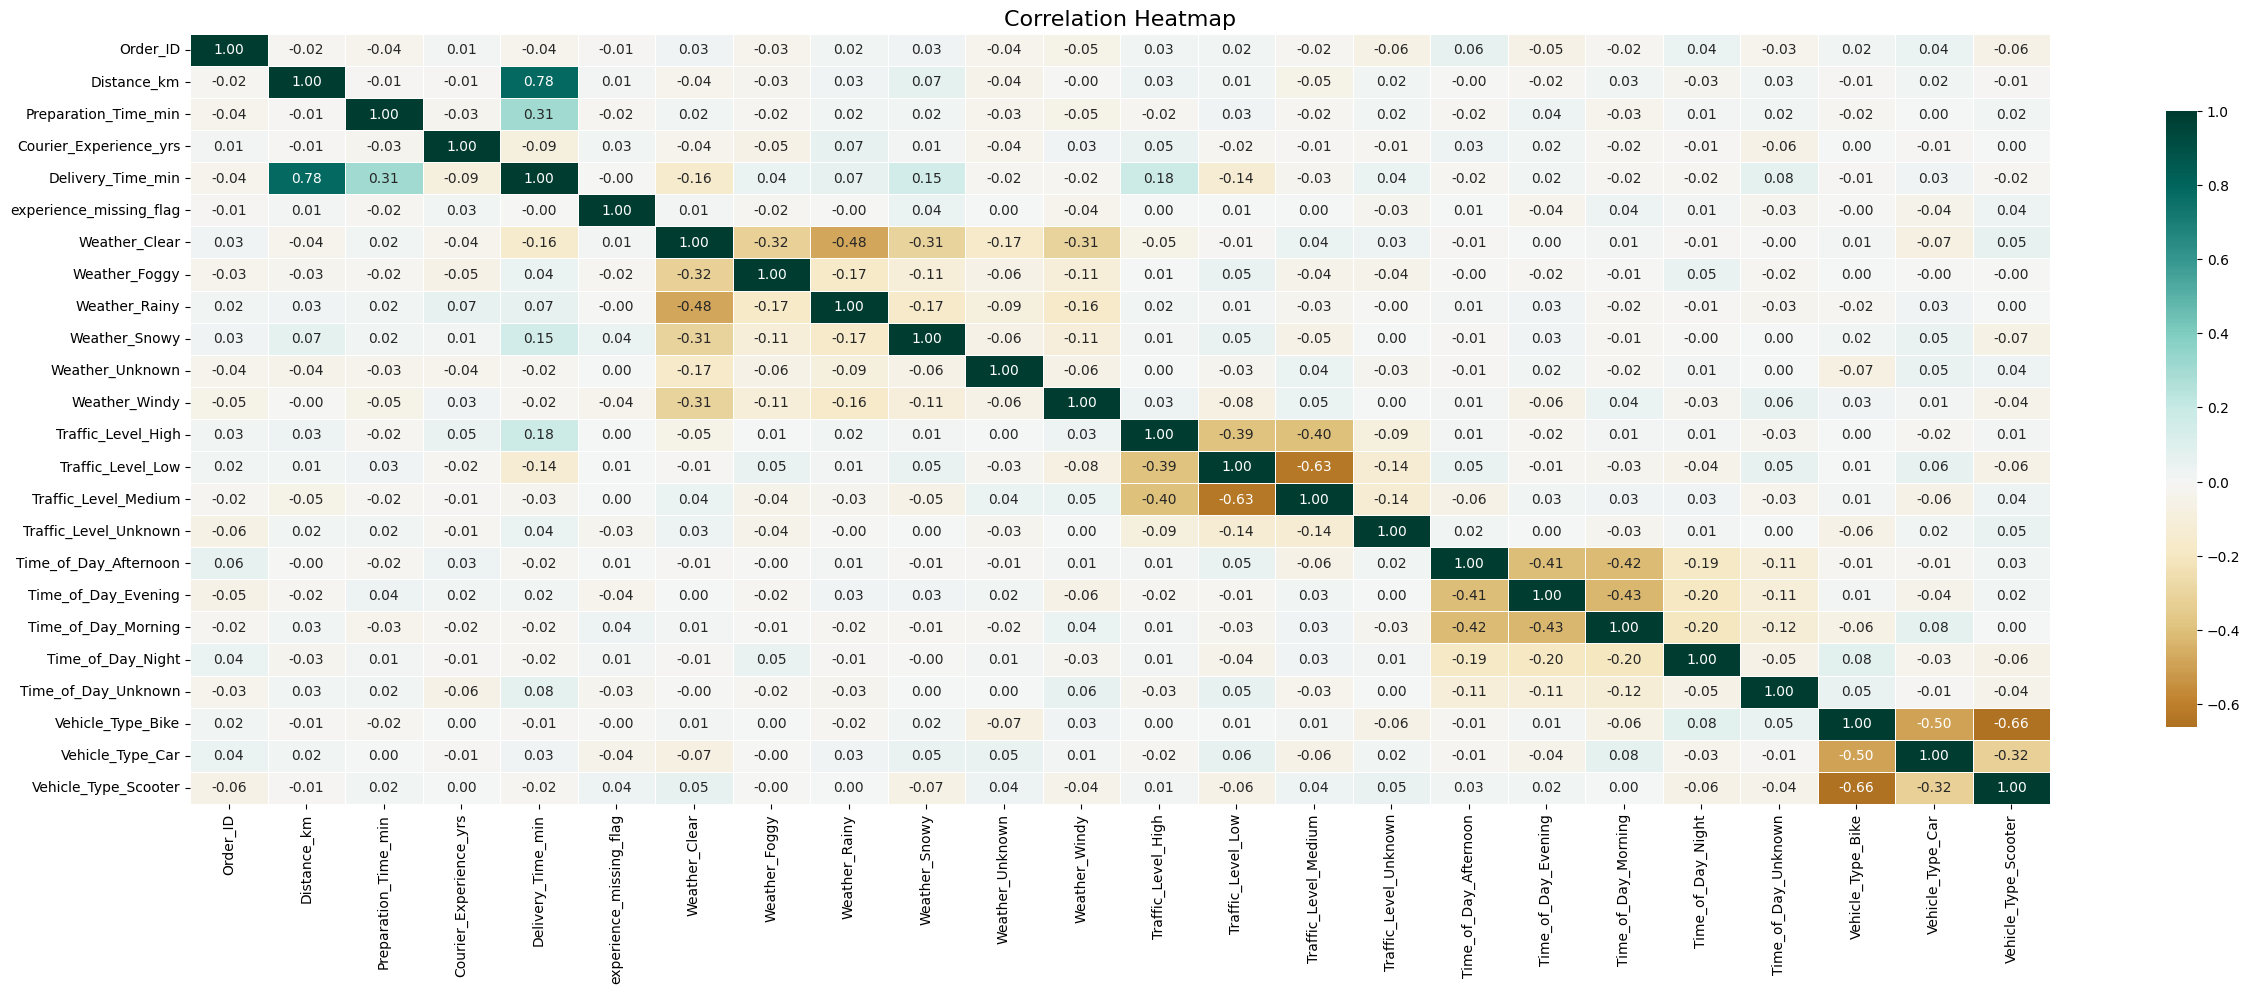

In [21]:
# correlation matrix dari semua variabel numerik
corr = df_EDA.select_dtypes(include='number').corr()

plt.figure(figsize=(30,10))

sns.heatmap(
    corr,
    cmap='BrBG',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap", fontsize=16)
plt.show()

### Correlation Heatmap Interpretation (Final)

#### 1. Variabel Utama yang Mempengaruhi Delivery Time
- *Distance_km* memiliki korelasi positif kuat (~0.78)  
  → Semakin jauh jarak, semakin lama waktu delivery  

- *Preparation_Time_min* memiliki korelasi positif sedang (~0.31)  
  → Waktu persiapan berkontribusi langsung terhadap durasi pengiriman  

---

#### 2. Pengaruh Kondisi Operasional
- *Traffic_Level_High* memiliki korelasi positif (~0.18)  
  → Kemacetan meningkatkan waktu delivery  

- *Traffic_Level_Low* memiliki korelasi negatif (~ -0.14)  
  → Lalu lintas lancar mempercepat delivery  

- *Weather_Snowy* memiliki korelasi positif (~0.15)  
  → Kondisi cuaca buruk (salju) cenderung memperlambat delivery  

---

#### 3. Variabel dengan Pengaruh Tambahan
- Variabel seperti *Time_of_Day* dan *Vehicle_Type* memiliki korelasi rendah  
  → Namun tetap relevan secara operasional untuk menangkap kondisi lapangan  

---

#### 4. Kesimpulan
- Faktor utama yang mempengaruhi delivery time adalah:
  - *Distance_km*
  - *Preparation_Time_min*  

- Faktor kondisi seperti traffic dan weather memberikan pengaruh tambahan  
- Variabel lainnya memiliki kontribusi yang lebih kecil terhadap target  

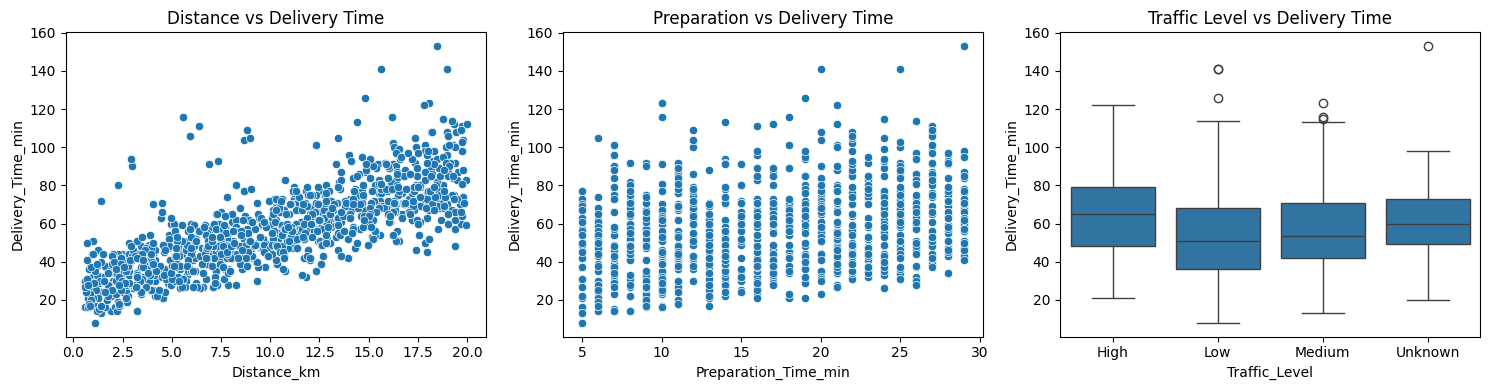

In [22]:
plt.figure(figsize=(15,4))

# Distance (numerical → scatter)
plt.subplot(1,3,1)
sns.scatterplot(x='Distance_km', y='Delivery_Time_min', data=df_finals)
plt.title('Distance vs Delivery Time')

# Preparation Time (numerical → scatter)
plt.subplot(1,3,2)
sns.scatterplot(x='Preparation_Time_min', y='Delivery_Time_min', data=df_finals)
plt.title('Preparation vs Delivery Time')

# Traffic Level (categorical → boxplot)
plt.subplot(1,3,3)
sns.boxplot(x='Traffic_Level', y='Delivery_Time_min', data=df_finals)
plt.title('Traffic Level vs Delivery Time')

plt.tight_layout()
plt.show()

### Interpretasi Visualisasi (Versi Manusiawi)

#### 1. Distance vs Delivery Time
- Terlihat jelas bahwa semakin jauh jarak (*Distance_km*), waktu pengiriman juga semakin lama  
- Polanya cukup linear dan konsisten  
- Artinya: jarak adalah faktor paling utama yang menentukan lamanya delivery  

👉 Intinya: kalau jarak naik, delivery time hampir pasti ikut naik  

---

#### 2. Preparation Time vs Delivery Time
- Semakin lama waktu persiapan (*Preparation_Time_min*), waktu delivery juga cenderung ikut meningkat  
- Tapi polanya tidak sekuat jarak (lebih menyebar)  
- Artinya: preparation time tetap berpengaruh, tapi bukan faktor utama  

👉 Intinya: preparation lama bikin delivery ikut lama, tapi pengaruhnya tidak sebesar jarak  

---

#### 3. Traffic Level vs Delivery Time
- Traffic *High* terlihat punya median delivery time paling tinggi  
- Traffic *Low* cenderung lebih cepat  
- Traffic *Medium* dan *Unknown* berada di tengah  

👉 Intinya:
- macet → delivery lebih lama  
- lancar → delivery lebih cepat  

---

#### Kesimpulan Besar
- Faktor paling dominan: *Distance_km*  
- Faktor pendukung:
  - *Preparation_Time_min*
  - *Traffic_Level*  

👉 Secara sederhana:
> Lama delivery itu ditentukan oleh jarak, ditambah kondisi operasional seperti waktu persiapan dan kemacetan

# Feature Engineering

## Experience Level

In [23]:
df_finals['experience_level'] = pd.cut(df_finals['Courier_Experience_yrs'],
    bins=[-1, 2, 5, 10],
    labels=['Low (0-2)', 'Medium (3-5)', 'High (6+)']
)

## Distance Group

In [24]:
df_finals['distance_group'] = pd.cut(
    df_finals['Distance_km'],
    bins=[0, 5, 10, 20],
    labels=['Near (0-5)', 'Medium (5-10)', 'Far (10+)']
)

## Preparation Time Group

In [25]:
df_finals['prep_time_group'] = pd.cut(
    df_finals['Preparation_Time_min'],
    bins=[0, 10, 20, 30],
    labels=['Fast Prep (0-10)', 'Normal Prep (10-20)', 'Slow Prep (20+)']
)

# Interaksi antar Variabel (Impact on Delivery Time (Minute))

## Distance x Traffic

In [26]:
pd.pivot_table(
    df_finals,
    values='Delivery_Time_min',
    index='distance_group',
    columns='Traffic_Level',
    aggfunc='mean',
    observed=False
)

Traffic_Level,High,Low,Medium,Unknown
distance_group,,,,
Near (0-5),41.659574,30.230769,34.638095,33.400000
Medium (5-10),57.790698,44.886598,49.225806,49.875000
Far (10+),77.794393,67.435897,71.005208,76.235294


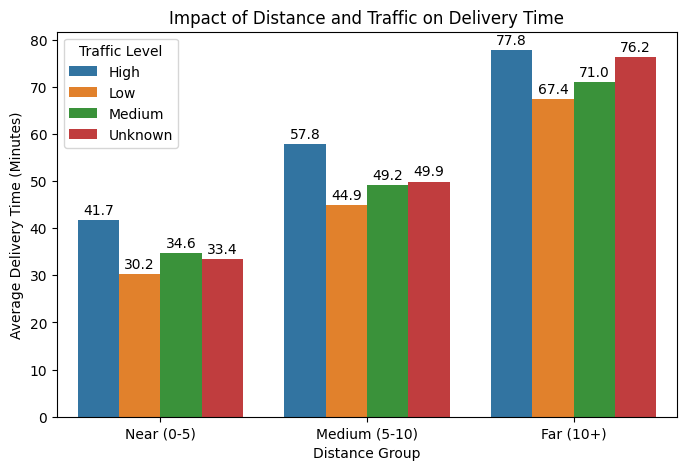

In [27]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=df_finals,
    x='distance_group',
    y='Delivery_Time_min',
    hue='Traffic_Level',
     errorbar=None
)

plt.title('Impact of Distance and Traffic on Delivery Time')
plt.xlabel('Distance Group')
plt.ylabel('Average Delivery Time (Minutes)')
plt.legend(title='Traffic Level')

# Annotation
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=2)

plt.show()

**Waktu pengiriman meningkat signifikan seiring bertambahnya jarak, dan semakin diperparah oleh kondisi traffic tinggi. Kombinasi jarak jauh dan kemacetan menjadi faktor utama keterlambatan delivery.**

## Distance x Preparation Time

In [28]:
pd.pivot_table(
    df_finals,
    values='Delivery_Time_min',
    index='distance_group',
    columns='prep_time_group',
    aggfunc='mean',
    observed=False
)

prep_time_group,Fast Prep (0-10),Normal Prep (10-20),Slow Prep (20+)
distance_group,,,
Near (0-5),25.562500,33.410526,41.606742
Medium (5-10),37.780000,47.336842,56.562500
Far (10+),61.469697,70.313433,79.528090


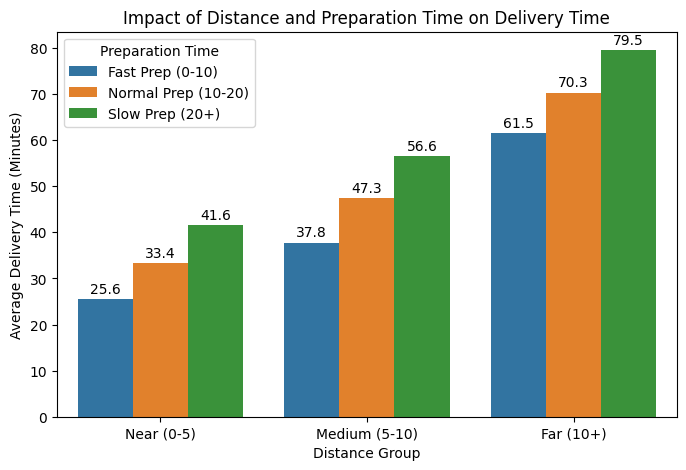

In [29]:
plt.figure(figsize=(8,5))

ax = sns.barplot( 
    data=df_finals,
    x='distance_group',
    y='Delivery_Time_min',
    hue='prep_time_group',
    errorbar=None
)

plt.title('Impact of Distance and Preparation Time on Delivery Time')
plt.xlabel('Distance Group')
plt.ylabel('Average Delivery Time (Minutes)')
plt.legend(title='Preparation Time')

# Annotation
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=2)

1. **Waktu persiapan memiliki dampak signifikan terhadap total delivery time di semua jarak**.
2. **Keterlambatan pada tahap preparation secara langsung meningkatkan durasi pengiriman, terutama pada jarak jauh, sehingga menjadi salah satu bottleneck utama dalam operasional delivery**.

## Traffic x Time of Day

In [30]:
pd.pivot_table(
    df_finals,
    values='Delivery_Time_min',
    index='Traffic_Level',
    columns='Time_of_Day',
    aggfunc='mean',
    observed=False
)

Time_of_Day,Afternoon,Evening,Morning,Night,Unknown
Traffic_Level,,,,,
High,64.224138,64.581818,64.193548,65.833333,81.250000
Low,51.016807,54.192661,52.035714,53.333333,63.062500
Medium,56.927835,56.633333,55.937008,52.108108,55.333333
Unknown,60.900000,65.222222,53.285714,46.666667,153.000000


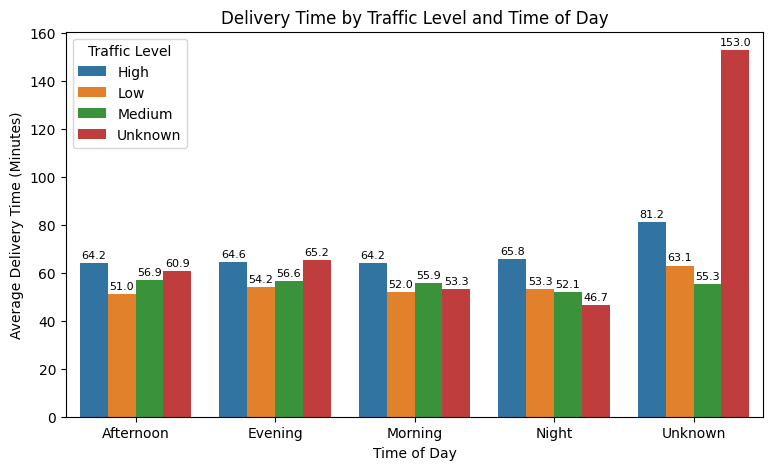

In [31]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=df_finals,
    x='Time_of_Day',
    y='Delivery_Time_min',
    hue='Traffic_Level',
    errorbar=None
)

plt.title('Delivery Time by Traffic Level and Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Average Delivery Time (Minutes)')
plt.legend(title='Traffic Level')

# Annotation
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=2, fontsize=8)

1. Waktu pengiriman lebih dipengaruhi oleh kondisi traffic dibandingkan waktu dalam sehari. 
2. Traffic tinggi secara konsisten menghasilkan durasi delivery yang lebih lama, 
3. sementara perbedaan antar waktu (morning, afternoon, dll) relatif kecil. 
4. Hal ini menunjukkan bahwa kemacetan menjadi faktor utama keterlambatan, bukan waktu operasional.

## Weather x Distance

In [32]:
pd.pivot_table(
    df_finals,
    values='Delivery_Time_min',
    index='Weather',
    columns='distance_group',
    aggfunc='mean',
    observed=False
)

distance_group,Near (0-5),Medium (5-10),Far (10+)
Weather,,,
Clear,30.318966,45.853448,67.701681
Foggy,40.640000,56.517241,70.816327
Rainy,37.400000,49.404255,74.822430
Snowy,43.863636,57.611111,79.087719
Unknown,36.416667,54.285714,73.545455
Windy,30.782609,46.625000,71.367347


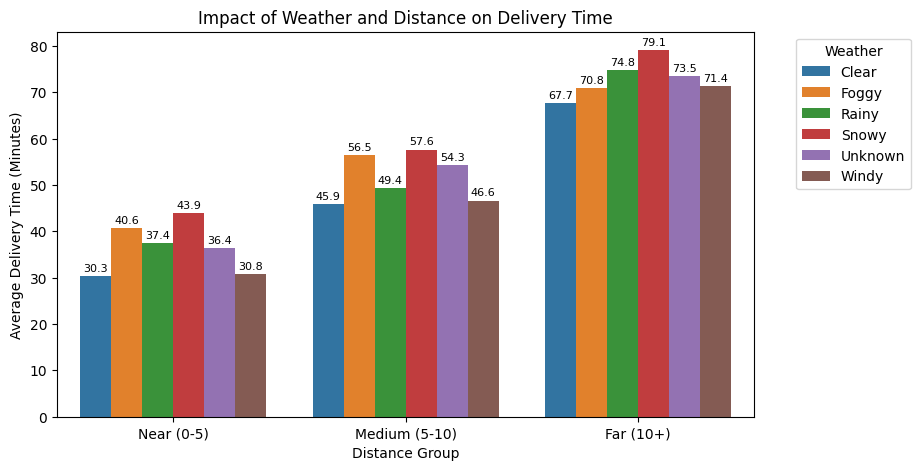

In [33]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=df_finals,
    x='distance_group',
    y='Delivery_Time_min',
    hue='Weather',
    errorbar=None
)

plt.title('Impact of Weather and Distance on Delivery Time')
plt.xlabel('Distance Group')
plt.ylabel('Average Delivery Time (Minutes)')
plt.legend(title='Weather', bbox_to_anchor=(1.05, 1), loc='upper left')

# Annotation
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=2, fontsize=8)

1. Waktu pengiriman meningkat seiring jarak, dan semakin tinggi pada kondisi cuaca buruk seperti hujan dan salju. 
2. Pengaruh cuaca terlihat lebih signifikan pada jarak jauh, menunjukkan bahwa kondisi eksternal dapat memperburuk durasi delivery terutama untuk pengiriman jarak panjang.

## Experience x Traffic

In [34]:
pd.pivot_table(
    df_finals,
    values='Delivery_Time_min',
    index='experience_level', 
    columns='Traffic_Level',
    aggfunc='mean',
    observed=False
)

Traffic_Level,High,Low,Medium,Unknown
experience_level,,,,
Low (0-2),70.021277,53.330508,58.090164,66.500000
Medium (3-5),65.033333,55.908257,55.456897,56.777778
High (6+),61.933333,50.435897,54.789474,62.363636


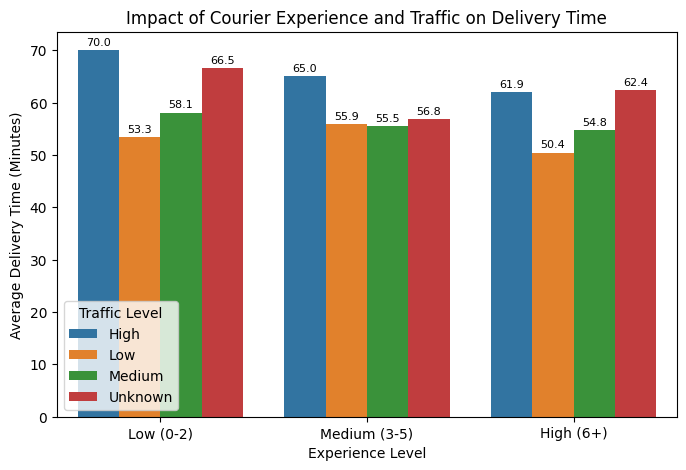

In [35]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=df_finals,
    x='experience_level',
    y='Delivery_Time_min',
    hue='Traffic_Level',
    errorbar=None
)

plt.title('Impact of Courier Experience and Traffic on Delivery Time')
plt.xlabel('Experience Level')
plt.ylabel('Average Delivery Time (Minutes)')
plt.legend(title='Traffic Level')

# Annotation
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=2, fontsize=8)

plt.show()

1. Pengalaman kurir membantu mempercepat waktu pengiriman, namun pengaruhnya relatif kecil dibandingkan kondisi traffic. 
2. Dalam semua level pengalaman, traffic tinggi tetap menghasilkan waktu delivery yang paling lama, menunjukkan bahwa kemacetan menjadi faktor dominan dibandingkan faktor manusia.

# Feature-Enhanced Dataset

In [36]:
df_finals.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,experience_missing_flag,experience_level,distance_group,prep_time_group
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,0,Low (0-2),Medium (5-10),Normal Prep (10-20)
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84,0,Low (0-2),Far (10+),Normal Prep (10-20)
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59,0,Low (0-2),Medium (5-10),Slow Prep (20+)
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,0,Low (0-2),Medium (5-10),Fast Prep (0-10)
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68,0,Medium (3-5),Far (10+),Normal Prep (10-20)


# Model Development

In [37]:
df_model = df_finals.copy()

In [38]:
# Import Library
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# PREPARE DATA

# Drop kolom yang tidak digunakan
df_model = df_finals.drop(['Order_ID', 'experience_missing_flag'], axis=1)

# Encoding categorical
df_model = pd.get_dummies(df_model, drop_first=True)

# Split X dan y
X = df_model.drop('Delivery_Time_min', axis=1)
y = df_model['Delivery_Time_min']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# MODEL
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

# EVALUATION FUNCTION
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

# TRAIN & EVALUATE
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae, rmse, mape = evaluate(y_test, y_pred)
    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "MAPE (%)": round(mape, 2)
    })

# HASIL AKHIR
results_df = pd.DataFrame(results)
results_df.sort_values(by="MAPE (%)")

,Model,MAE,RMSE,MAPE (%)
0,Linear Regression,5.93,8.78,10.69
2,Random Forest,7.13,10.30,13.26
1,Decision Tree,11.34,16.33,20.95


# Modelling for Prediction Delivery Time

In [39]:
# PREPARE DATA

# Drop kolom tidak penting
df_model = df_finals.drop(['Order_ID', 'experience_missing_flag'], axis=1)

# Encoding categorical
df_model = pd.get_dummies(df_model, drop_first=True)

# Split fitur & target
X = df_model.drop('Delivery_Time_min', axis=1)
y = df_model['Delivery_Time_min']

# TRAIN FINAL MODEL (FULL DATA)
model = LinearRegression()
model.fit(X, y)

# EVALUASI (DI DATA YANG SAMA)
y_pred = model.predict(X)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mape = np.mean(np.abs((y - y_pred) / y)) * 100
print("=== MODEL PERFORMANCE ===")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")


# FEATURE IMPORTANCE (COEFFICIENT)
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)
print("\n=== FEATURE IMPORTANCE ===")
display(coeff_df)

# CONTOH PREDIKSI (1 DATA)
# Ambil 1 sample data
sample = X.iloc[[0]]
pred = model.predict(sample)
print("\n=== SAMPLE PREDICTION ===")
print("Actual  :", y.iloc[0])
print("Predicted:", round(pred[0], 2))

=== MODEL PERFORMANCE ===
MAE  : 6.44
RMSE : 10.31
MAPE : 10.85%

=== FEATURE IMPORTANCE ===


,Feature,Coefficient
5,Weather_Snowy,9.613003
3,Weather_Foggy,7.844241
14,Time_of_Day_Unknown,7.372309
4,Weather_Rainy,5.374642
6,Weather_Unknown,4.984742
0,Distance_km,2.928558
7,Weather_Windy,2.071327
20,distance_group_Far (10+),1.035683
1,Preparation_Time_min,0.981907
11,Time_of_Day_Evening,0.784609



=== SAMPLE PREDICTION ===
Actual  : 43
Predicted: 41.09


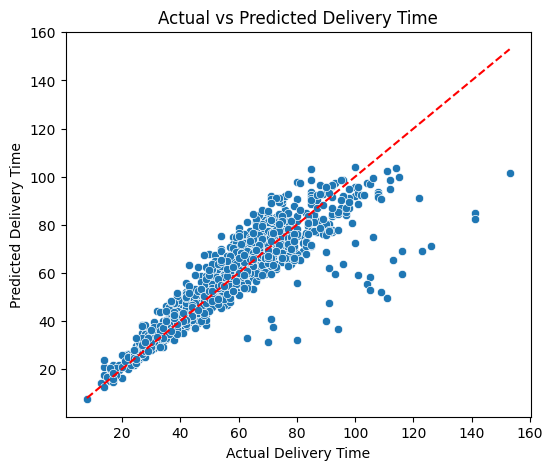

In [40]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=y, y=y_pred)

plt.xlabel('Actual Delivery Time')
plt.ylabel('Predicted Delivery Time')
plt.title('Actual vs Predicted Delivery Time')

# garis ideal
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')

plt.show()

In [41]:
df_result = df_finals.copy()
df_result['Predicted_Delivery_Time'] = y_pred

# Create Final Dataset for Power BI Visualization

In [42]:
df_result.to_csv('df_result.csv', index = False)

In [43]:
# checking validasi 

df_cek = pd.read_csv('df_result.csv')
df_cek.head(10)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,experience_missing_flag,experience_level,distance_group,prep_time_group,Predicted_Delivery_Time
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,0,Low (0-2),Medium (5-10),Normal Prep (10-20),41.094197
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84,0,Low (0-2),Far (10+),Normal Prep (10-20),79.337820
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59,0,Low (0-2),Medium (5-10),Slow Prep (20+),66.077690
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,0,Low (0-2),Medium (5-10),Fast Prep (0-10),41.614885
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68,0,Medium (3-5),Far (10+),Normal Prep (10-20),74.472393
5,679,19.40,Clear,Low,Evening,Scooter,8,9.0,57,0,High (6+),Far (10+),Fast Prep (0-10),65.073411
6,627,9.52,Clear,Low,Unknown,Bike,12,1.0,49,0,Low (0-2),Medium (5-10),Normal Prep (10-20),51.993906
7,514,17.39,Clear,Medium,Evening,Scooter,5,6.0,46,0,High (6+),Far (10+),Fast Prep (0-10),62.522246
8,860,1.78,Snowy,Low,Evening,Car,20,6.0,35,0,High (6+),Near (0-5),Normal Prep (10-20),36.007156
9,137,10.62,Foggy,Low,Evening,Scooter,29,1.0,73,0,Low (0-2),Far (10+),Slow Prep (20+),72.193341


In [44]:
df_result.drop('experience_missing_flag', axis=1, inplace=True)

In [45]:
df_result

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,experience_level,distance_group,prep_time_group,Predicted_Delivery_Time
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,Low (0-2),Medium (5-10),Normal Prep (10-20),41.094197
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84,Low (0-2),Far (10+),Normal Prep (10-20),79.337820
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59,Low (0-2),Medium (5-10),Slow Prep (20+),66.077690
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,Low (0-2),Medium (5-10),Fast Prep (0-10),41.614885
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68,Medium (3-5),Far (10+),Normal Prep (10-20),74.472393
5,679,19.40,Clear,Low,Evening,Scooter,8,9.0,57,High (6+),Far (10+),Fast Prep (0-10),65.073411
6,627,9.52,Clear,Low,Unknown,Bike,12,1.0,49,Low (0-2),Medium (5-10),Normal Prep (10-20),51.993906
7,514,17.39,Clear,Medium,Evening,Scooter,5,6.0,46,High (6+),Far (10+),Fast Prep (0-10),62.522246
8,860,1.78,Snowy,Low,Evening,Car,20,6.0,35,High (6+),Near (0-5),Normal Prep (10-20),36.007156
9,137,10.62,Foggy,Low,Evening,Scooter,29,1.0,73,Low (0-2),Far (10+),Slow Prep (20+),72.193341


In [46]:
df_results = df_result.copy()

In [47]:
df_results.to_csv('df_results.csv', index = False)

In [48]:
# checking validasi 

df_cek = pd.read_csv('df_results.csv')
df_cek.head(10)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,experience_level,distance_group,prep_time_group,Predicted_Delivery_Time
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,Low (0-2),Medium (5-10),Normal Prep (10-20),41.094197
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84,Low (0-2),Far (10+),Normal Prep (10-20),79.337820
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59,Low (0-2),Medium (5-10),Slow Prep (20+),66.077690
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,Low (0-2),Medium (5-10),Fast Prep (0-10),41.614885
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68,Medium (3-5),Far (10+),Normal Prep (10-20),74.472393
5,679,19.40,Clear,Low,Evening,Scooter,8,9.0,57,High (6+),Far (10+),Fast Prep (0-10),65.073411
6,627,9.52,Clear,Low,Unknown,Bike,12,1.0,49,Low (0-2),Medium (5-10),Normal Prep (10-20),51.993906
7,514,17.39,Clear,Medium,Evening,Scooter,5,6.0,46,High (6+),Far (10+),Fast Prep (0-10),62.522246
8,860,1.78,Snowy,Low,Evening,Car,20,6.0,35,High (6+),Near (0-5),Normal Prep (10-20),36.007156
9,137,10.62,Foggy,Low,Evening,Scooter,29,1.0,73,Low (0-2),Far (10+),Slow Prep (20+),72.193341
